# Week 4: NLP Disaster Tweets Kaggle Mini-Project

## 1) Introduction

My startpoint was the starter notebook provided by the Keras team. https://keras.io/guides/keras_nlp/getting_started/

The starter notebook uses the DistilBERT pretrained model from KerasNLP.  **BERT** stands for **Bidirectional Encoder Representations from Transformers**. BERT and other Transformer encoder architectures have been wildly successful on a variety of tasks in NLP (natural language processing). They compute vector-space representations of natural language that are suitable for use in deep learning models. The BERT family of models uses the **Transformer encoder architecture** to process each token of input text in the full context of all tokens before and after, hence the name: Bidirectional Encoder Representations from Transformers. BERT models are usually pre-trained on a large corpus of text, then fine-tuned for specific tasks. **DistilBERT model** is a distilled form of the **BERT** model. The size of a BERT model was reduced by 40% via knowledge distillation during the pre-training phase while retaining 97% of its language understanding abilities and being 60% faster.

This will be one of the models I use, but, looking at the project instructions: I will also look at one other "build from scratch" RNN/LSTM/GRU type model.

In [107]:
import os
import sys
import time
from pathlib import Path
from datetime import datetime
import warnings

from tqdm import tqdm
import gc
import random

import tensorflow as tf
import keras_core as keras
import keras_nlp


import re
import string
import operator
from collections import defaultdict
from wordcloud import STOPWORDS

import platform
from tensorflow.keras import mixed_precision

os.environ['KERAS_BACKEND'] = 'tensorflow'

# Determine if we're running locally or in Kaggle'
KAGGLE_ENV = os.path.exists('/kaggle/input')
if KAGGLE_ENV:
    print("Using Kaggle competition data")
    DATA_DIR = Path('/kaggle/input/nlp-getting-started')
else:
    print("Running locally with downloaded Kaggle data")
    DATA_DIR = Path("nlp-getting-started")

    # Set up for Apple Silicon GPU acceleration - locally I run a MacBook Pro M1
    is_macos = platform.system() == "Darwin"
    if is_macos:
        print(f"Running on macOS: {is_macos}")

        USE_MIXED_PRECISION = True  # Not always a good idea, so use variable to turn on/off

        # Enable GPU acceleration if available
        print("Metal GPU Available: ", len(tf.config.list_physical_devices('GPU')) > 0)
        if tf.config.list_physical_devices('GPU'):
            print("Using GPU acceleration with Metal")
            for gpu in tf.config.list_physical_devices('GPU'):
                tf.config.experimental.set_memory_growth(gpu, True)
        else:
            print("GPU not available, using CPU")
        # Enable mixed precision policy
        if USE_MIXED_PRECISION:
            policy = mixed_precision.Policy('mixed_float16')
        else:
            policy = mixed_precision.Policy('float32')
        mixed_precision.set_global_policy(policy)
        print(f"Mixed precision policy set to: {policy}")

print("Python:", sys.version.split()[0])
print("TensorFlow version:", tf.__version__)
print("KerasNLP version:", keras_nlp.__version__)

Running locally with downloaded Kaggle data
Running on macOS: True
Metal GPU Available:  True
Using GPU acceleration with Metal
Mixed precision policy set to: <DTypePolicy "mixed_float16">
Python: 3.11.13
TensorFlow version: 2.19.1
KerasNLP version: 0.22.2


In [99]:
# Handle other imports and project setup requirements
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# paths
OUTPUT_DIR = Path("./outputs/5511_module4")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
FIG_DIR = Path("./figs/5511_module4")
FIG_DIR.mkdir(exist_ok=True, parents=True)
MODEL_DIR = Path("./models/5511_module4")
MODEL_DIR.mkdir(exist_ok=True, parents=True)

# Plotting defaults
sns.set_theme(context="notebook", style="darkgrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

# helper function to save figures
def save_figure(name=None, dpi=300, bbox_inches='tight', pad_inches=0.1):
    # Generate filename
    if name is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"chart_{timestamp}.png"
    else:
        # Clean the name to be filename-safe
        filename = "".join(c for c in name if c.isalnum() or c in (' ', '-', '_')).rstrip()
        filename = filename.replace(' ', '_')
        if not filename.endswith('.png'):
            filename += '.png'
    # Full path
    filepath = os.path.join(FIG_DIR, filename)
    # Save the figure
    plt.savefig(filepath, dpi=dpi, bbox_inches=bbox_inches, pad_inches=pad_inches)
    print(f"Figure saved: {filepath}")
    return filepath

# Import tokenization - a python module from Guines Evitan's Kaggle notebook' (see citations)
current_dir = os.getcwd()
src_path = os.path.join(current_dir, 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)
try:
    from nlp import tokenization
    print("Successfully imported tokenization module")
except ImportError as e:
    print(f"Failed to import tokenization: {e}")

Successfully imported tokenization module


## 2) Brief description of the problem and data
_Briefly describe the challenge problem and NLP. Describe the size, dimension, structure, etc., of the data._


### Challenge Problem
In the Kaggle competition, the challenge is to build an NLP machine learning model that predicts which Tweets are about real disasters and which ones aren’t.

In addition, the project scoring rubrik requires various criteria are met. These are set out in _italics_ under each section heading.

The data is available in two files:
- train.csv: 10,000 tweets that were hand-classified
- test.csv: 10,000 tweets that were not hand-classified

### Data Description
- id
- keyword: A keyword from that tweet (although this may be blank!)
- location: The location the tweet was sent from (may also be blank)
- text: The text of a tweet
- target: 1 if the tweet is a real disaster or 0 if not

In [62]:
df_train = pd.read_csv("nlp-getting-started/train.csv")
df_test = pd.read_csv("nlp-getting-started/test.csv")

print('Training Set Shape = {}'.format(df_train.shape))
print('Training Set Memory Usage = {:.2f} MB'.format(df_train.memory_usage().sum() / 1024**2))
print('Test Set Shape = {}'.format(df_test.shape))
print('Test Set Memory Usage = {:.2f} MB'.format(df_test.memory_usage().sum() / 1024**2))
display(df_train.head())
display(df_test.head())

Training Set Shape = (7613, 5)
Training Set Memory Usage = 0.29 MB
Test Set Shape = (3263, 4)
Test Set Memory Usage = 0.10 MB


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


## 3) Exploratory Data Analysis (EDA) — Inspect, Visualize and Clean the Data
_Show a few visualizations like histograms. Describe any data cleaning procedures. Based on your EDA, what is your plan of analysis?_

_**NOTE**: The EDA is pretty much coming from Guines Evitan's Kaggle notebook. (see citations) I have cleaned a little and filtered for what I want, but nothing much more is original. What I include here, is mostly for personal learning and reference. It also supports subsequent cleaning in pre-processing._

### EDA Approach
- Check basic stats re tweets (length, mean, std, etc.)
- Check and fix missing values (already know from Kaggle, that this is in 'Keyword' and 'Location' columns)
- Check distribution of target classes
- Check distribution of top keywords per class
- Add meta features and analyse
- Bigrams (Frequency analysis by class)

In [63]:
df_train["length"] = df_train["text"].apply(lambda x : len(x))
df_test["length"] = df_test["text"].apply(lambda x : len(x))

print("Train Length Stat")
print(df_train["length"].describe())
print()

print("Test Length Stat")
print(df_test["length"].describe())

Train Length Stat
count    7613.000000
mean      101.037436
std        33.781325
min         7.000000
25%        78.000000
50%       107.000000
75%       133.000000
max       157.000000
Name: length, dtype: float64

Test Length Stat
count    3263.000000
mean      102.108183
std        33.972158
min         5.000000
25%        78.000000
50%       109.000000
75%       134.000000
max       151.000000
Name: length, dtype: float64


In [64]:
# Missing values: there are similar numbers of missing values for keyword and location in train and test
for df in [df_train,df_test]:
    for col in df.columns:
        if df[col].isnull().values.any():
            print(f"Filling missing {df[col].isnull().sum()} values in {col}")
            df[col] = df[col].fillna(f'no_{col}')
print("Confirm all missing values are now filled:",
        f"Train: {df_train.isnull().values.any() == False}",
        f"Test: {df_test.isnull().values.any() == False}")

Filling missing 61 values in keyword
Filling missing 2533 values in location
Filling missing 26 values in keyword
Filling missing 1105 values in location
Confirm all missing values are now filled: Train: True Test: True


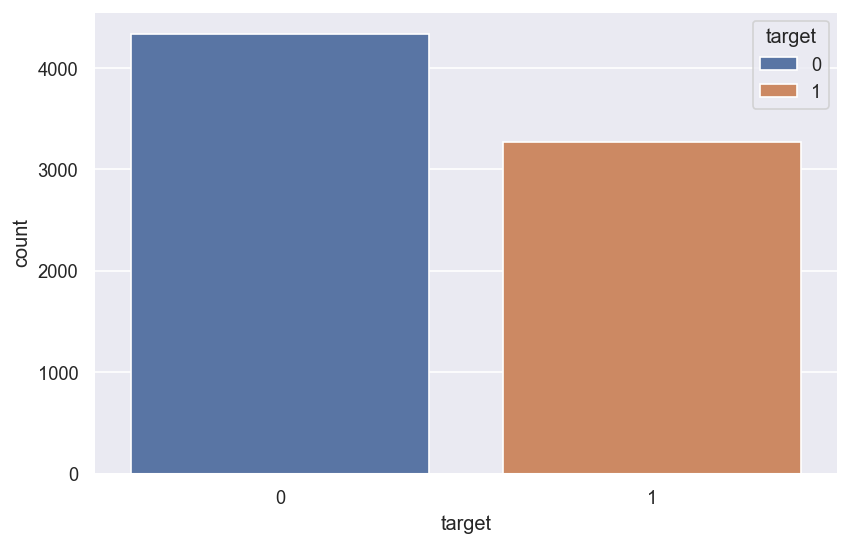

In [104]:
# Check class distribution
sns.countplot(x="target", data=df_train,hue=df_train['target'])
plt.show()

In [65]:
print(f'Number of unique values in keyword = {df_train["keyword"].nunique()} (Training) - {df_test["keyword"].nunique()} (Test)')
print(f'Number of unique values in location = {df_train["location"].nunique()} (Training) - {df_test["location"].nunique()} (Test)')

Number of unique values in keyword = 222 (Training) - 222 (Test)
Number of unique values in location = 3342 (Training) - 1603 (Test)


Figure saved: figs/5511_module4/top_20_keywords_per_class.png


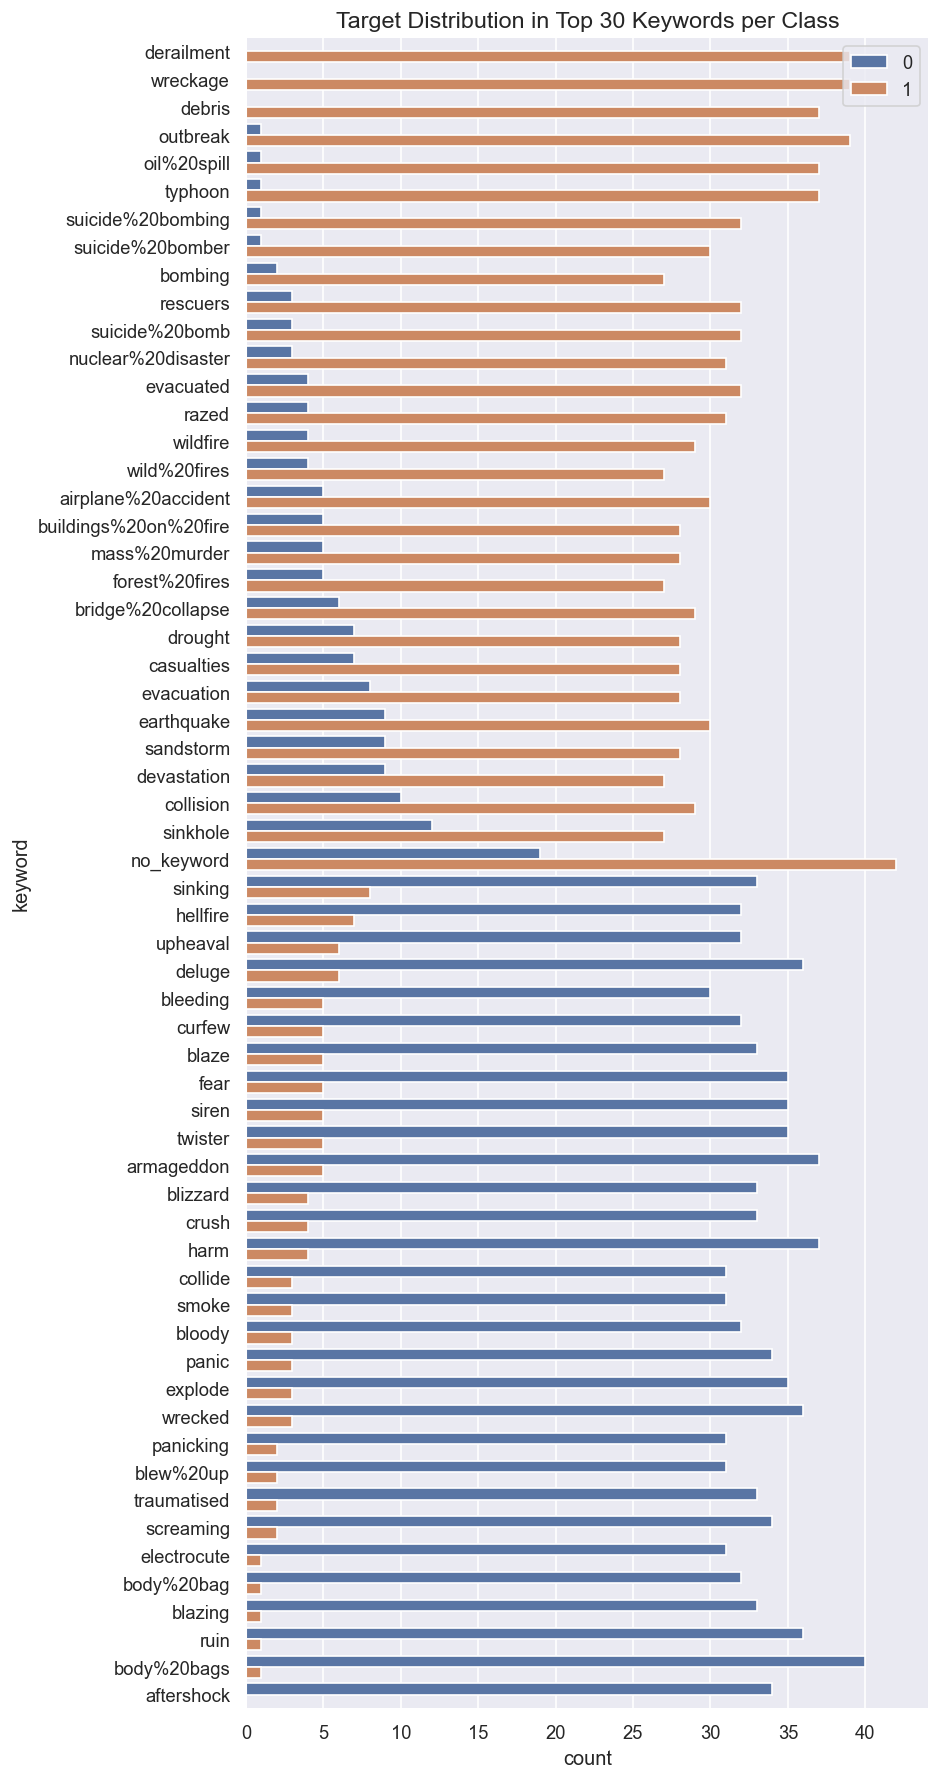

In [78]:
# Get top 20 keywords for each target class
num_keywords = 30
top_disaster = df_train[df_train['target'] == 1]['keyword'].value_counts().head(num_keywords).index
top_non_disaster = df_train[df_train['target'] == 0]['keyword'].value_counts().head(num_keywords).index
top_keywords = (list(top_disaster) + list(top_non_disaster))

# Filter the dataframe to only include these keywords
df_filtered = df_train[df_train['keyword'].isin(top_keywords)].copy()
df_filtered.loc[:, 'target_mean'] = df_filtered.groupby('keyword')['target'].transform('mean')

fig = plt.figure(figsize=(8, num_keywords *.5))  # Adjusted height for potentially up to 40 keywords

sns.countplot(y=df_filtered.sort_values(by='target_mean', ascending=False)['keyword'],
              hue=df_filtered.sort_values(by='target_mean', ascending=False)['target'])

plt.legend(loc=1)
plt.title(f'Target Distribution in Top {num_keywords} Keywords per Class')
plt.tight_layout()
save_figure("top_20_keywords_per_class")
plt.show()

The meta features used for the analysis are:
- word_count number of words in text
- unique_word_count number of unique words in text
- stop_word_count number of stop words in text
- url_count number of urls in text
- mean_word_length average character count in words
- char_count number of characters in text
- punctuation_count number of punctuations in text
- hashtag_count number of hashtags (#) in text
- mention_count number of mentions (@) in text

In [83]:
# word_count
df_train['word_count'] = df_train['text'].apply(lambda x: len(str(x).split()))
df_test['word_count'] = df_test['text'].apply(lambda x: len(str(x).split()))

# unique_word_count
df_train['unique_word_count'] = df_train['text'].apply(lambda x: len(set(str(x).split())))
df_test['unique_word_count'] = df_test['text'].apply(lambda x: len(set(str(x).split())))

# stop_word_count
df_train['stop_word_count'] = df_train['text'].apply(lambda x: len([w for w in str(x).lower().split() if w in STOPWORDS]))
df_test['stop_word_count'] = df_test['text'].apply(lambda x: len([w for w in str(x).lower().split() if w in STOPWORDS]))

# url_count
df_train['url_count'] = df_train['text'].apply(lambda x: len([w for w in str(x).lower().split() if 'http' in w or 'https' in w]))
df_test['url_count'] = df_test['text'].apply(lambda x: len([w for w in str(x).lower().split() if 'http' in w or 'https' in w]))

# mean_word_length
df_train['mean_word_length'] = df_train['text'].apply(lambda x: np.mean([len(w) for w in str(x).split()]))
df_test['mean_word_length'] = df_test['text'].apply(lambda x: np.mean([len(w) for w in str(x).split()]))

# char_count
df_train['char_count'] = df_train['text'].apply(lambda x: len(str(x)))
df_test['char_count'] = df_test['text'].apply(lambda x: len(str(x)))

# punctuation_count
df_train['punctuation_count'] = df_train['text'].apply(lambda x: len([c for c in str(x) if c in string.punctuation]))
df_test['punctuation_count'] = df_test['text'].apply(lambda x: len([c for c in str(x) if c in string.punctuation]))

# hashtag_count
df_train['hashtag_count'] = df_train['text'].apply(lambda x: len([c for c in str(x) if c == '#']))
df_test['hashtag_count'] = df_test['text'].apply(lambda x: len([c for c in str(x) if c == '#']))

# mention_count
df_train['mention_count'] = df_train['text'].apply(lambda x: len([c for c in str(x) if c == '@']))
df_test['mention_count'] = df_test['text'].apply(lambda x: len([c for c in str(x) if c == '@']))

Figure saved: figs/5511_module4/meta_features_target_distribution.png


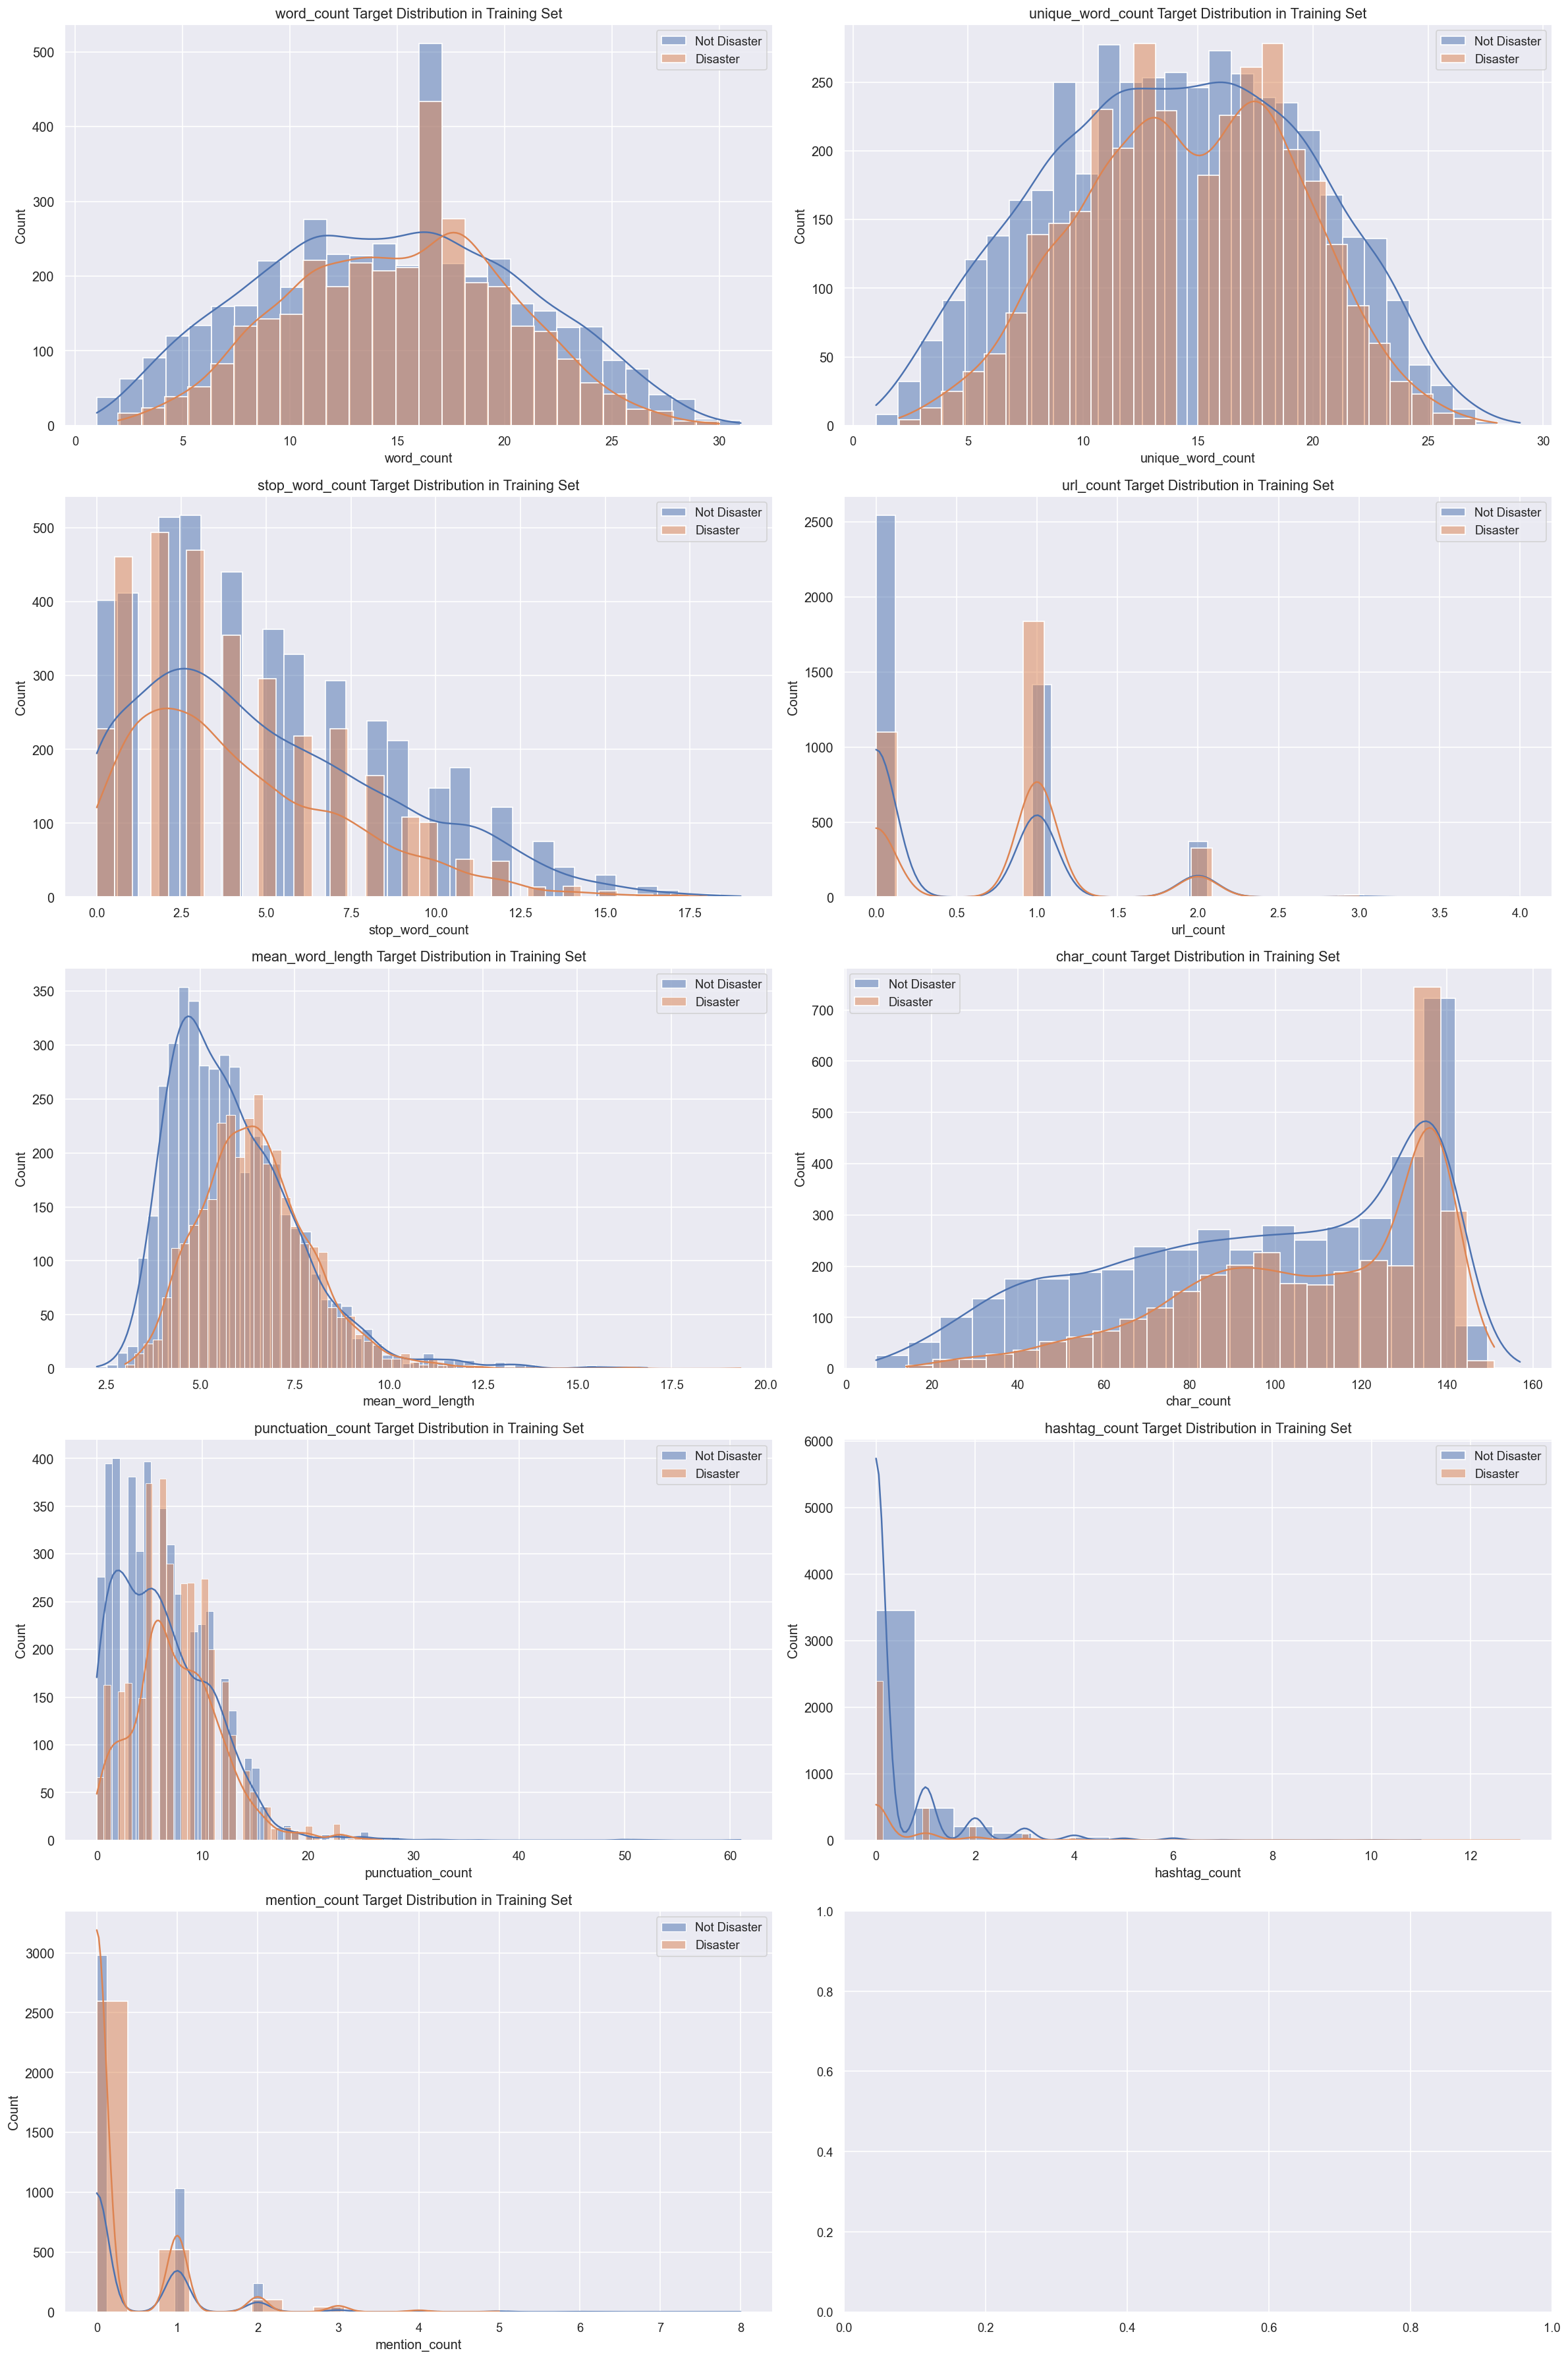

In [110]:
METAFEATURES = ['word_count', 'unique_word_count', 'stop_word_count', 'url_count', 'mean_word_length',
                'char_count', 'punctuation_count', 'hashtag_count', 'mention_count']
DISASTER_TWEETS = df_train['target'] == 1

fig, axes = plt.subplots(ncols=2, nrows=int(len(METAFEATURES)/2 +.5), figsize=(20, 30))

for i, feature in enumerate(METAFEATURES):
    r,c = i //2, i %2
    sns.histplot(df_train.loc[~DISASTER_TWEETS][feature], kde=True, label='Not Disaster', ax=axes[r][c])
    sns.histplot(df_train.loc[DISASTER_TWEETS][feature], kde=True, label='Disaster', ax=axes[r][c])
    axes[r][c].tick_params(axis='y', labelsize=12)
    axes[r][c].legend()
    axes[r][c].set_title(f'{feature} Target Distribution in Training Set', fontsize=13)
plt.tight_layout()
save_figure("meta_features_target_distribution")
plt.show()

In [105]:
# Analyse bigrams
# Generate ngrams for each tweet and count the number of times each ngram appears in each class.
def generate_ngrams(text, n_gram=1):
    token = [token for token in text.lower().split(' ') if token != '' if token not in STOPWORDS]
    ngrams = zip(*[token[i:] for i in range(n_gram)])
    return [' '.join(ngram) for ngram in ngrams]

N = 100

# Unigrams
disaster_unigrams = defaultdict(int)
nondisaster_unigrams = defaultdict(int)

for tweet in df_train[DISASTER_TWEETS]['text']:
    for word in generate_ngrams(tweet):
        disaster_unigrams[word] += 1

for tweet in df_train[~DISASTER_TWEETS]['text']:
    for word in generate_ngrams(tweet):
        nondisaster_unigrams[word] += 1

df_disaster_unigrams = pd.DataFrame(sorted(disaster_unigrams.items(), key=lambda x: x[1])[::-1])
df_nondisaster_unigrams = pd.DataFrame(sorted(nondisaster_unigrams.items(), key=lambda x: x[1])[::-1])

# Bigrams
disaster_bigrams = defaultdict(int)
nondisaster_bigrams = defaultdict(int)

for tweet in df_train[DISASTER_TWEETS]['text']:
    for word in generate_ngrams(tweet, n_gram=2):
        disaster_bigrams[word] += 1

for tweet in df_train[~DISASTER_TWEETS]['text']:
    for word in generate_ngrams(tweet, n_gram=2):
        nondisaster_bigrams[word] += 1

df_disaster_bigrams = pd.DataFrame(sorted(disaster_bigrams.items(), key=lambda x: x[1])[::-1])
df_nondisaster_bigrams = pd.DataFrame(sorted(nondisaster_bigrams.items(), key=lambda x: x[1])[::-1])

Figure saved: figs/5511_module4/top_bigrams.png


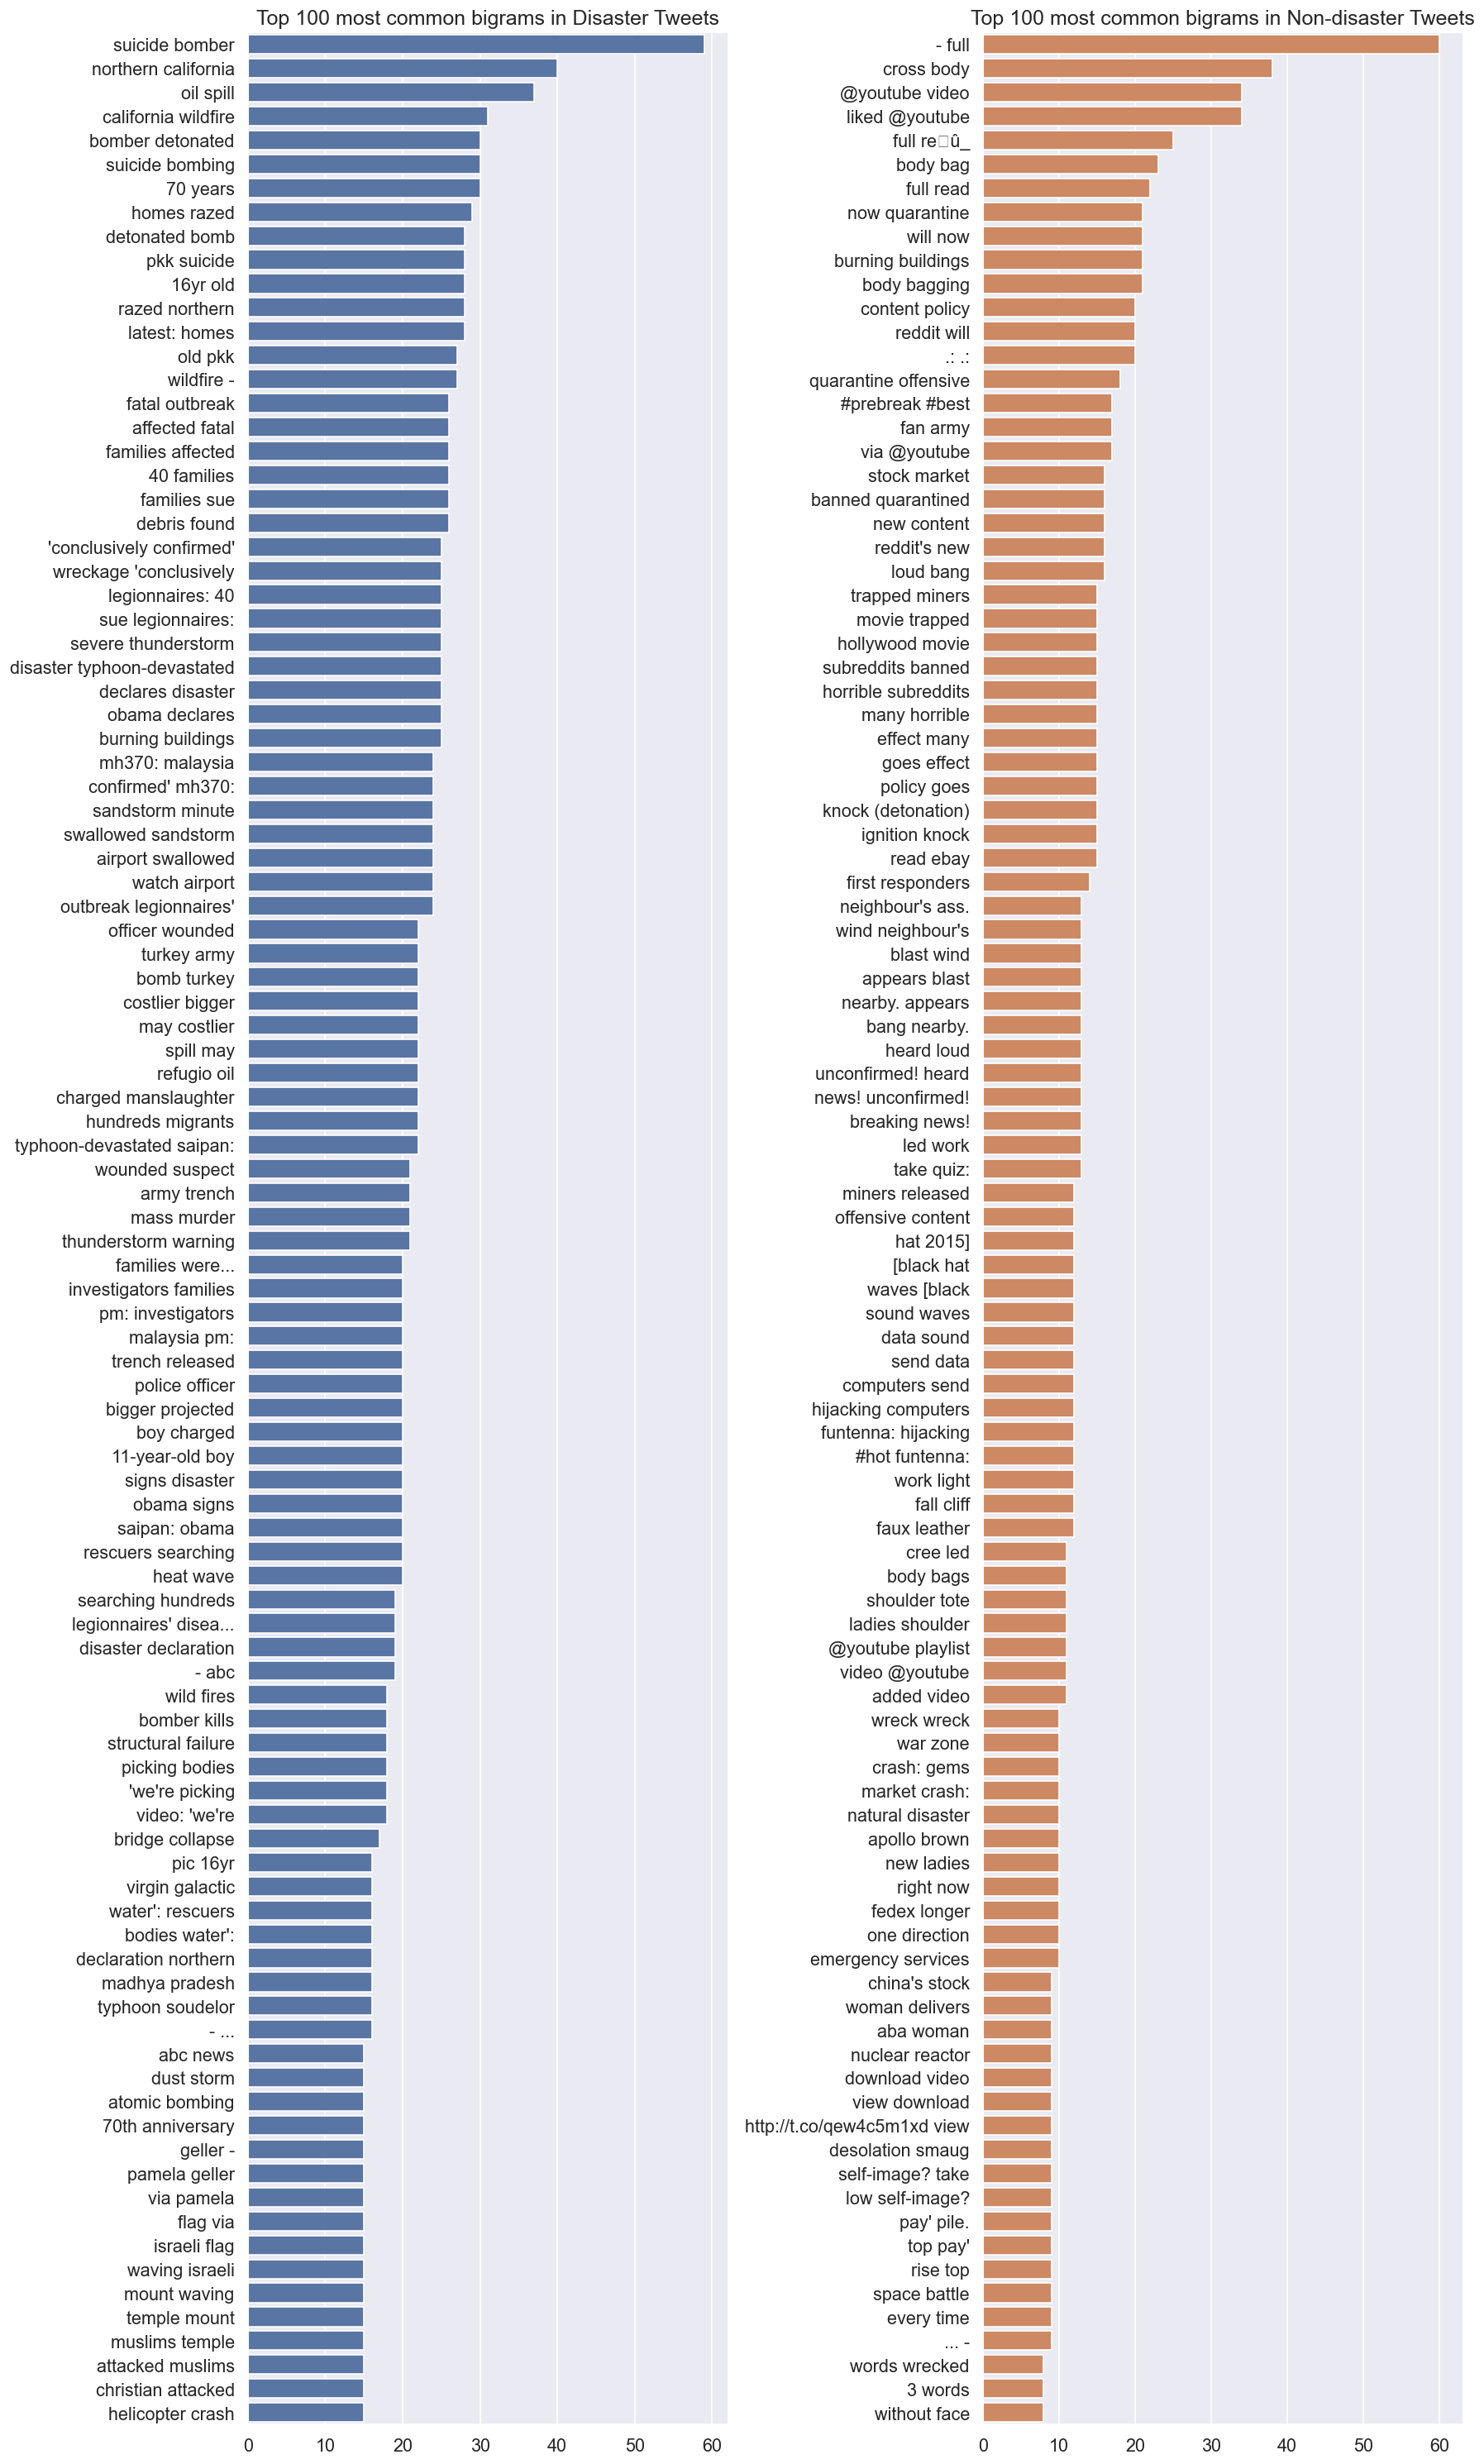

In [109]:
fig, axes = plt.subplots(ncols=2, figsize=(15, 25))

sns.barplot(y=df_disaster_bigrams[0].values[:N], x=df_disaster_bigrams[1].values[:N], ax=axes[0], color=sns.color_palette("deep")[0])
sns.barplot(y=df_nondisaster_bigrams[0].values[:N], x=df_nondisaster_bigrams[1].values[:N], ax=axes[1], color=sns.color_palette("deep")[1])

for i in range(2):
    axes[i].spines['right'].set_visible(False)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', labelsize=13)
    axes[i].tick_params(axis='y', labelsize=13)

axes[0].set_title(f'Top {N} most common bigrams in Disaster Tweets', fontsize=15)
axes[1].set_title(f'Top {N} most common bigrams in Non-disaster Tweets', fontsize=15)
warnings.filterwarnings('ignore', message='Glyph.*missing from font.*')

plt.tight_layout()
save_figure("top_bigrams")
plt.show()

### EDA Observations
- Note that all the tweets are in English.
- The average tweet length is 100 characters.
- The train and test data sets are taken from the same distribution.
- The distribution of the target classes is similar (see distributions of meta features for evidence), so limited requirement for stratification.
- unique_word_count, mean_word_length & punctuation_count have different distributions for disaster and non-disaster tweets.
- Bigrams for diasters tend to be more informative. Clearly, there is a need to strip punctuation and special characters.
- Interesting to note the conclusion from Guines (on Kaggle) that the distributions show tweets about diasters more likely to come from news organizations: (formal, less grammar/spelling errors); whilst those about non-disaster more likely to come from individuals: (more reference to social media, informal). This is not something I would have noted, but it seems a rational explanation for what we see in the bigram charts.

### EDA Observations
- Note that all the tweets are in English.
- The average tweet length is 100 characters.

## 4) Preprocessing

In [7]:
BATCH_SIZE = 32
NUM_TRAINING_EXAMPLES = df_train.shape[0]
TRAIN_SPLIT = 0.8
VAL_SPLIT = 0.2
STEPS_PER_EPOCH = int(NUM_TRAINING_EXAMPLES)*TRAIN_SPLIT // BATCH_SIZE

EPOCHS = 2
AUTO = tf.data.experimental.AUTOTUNE

In [8]:
from sklearn.model_selection import train_test_split

X = df_train["text"]
y = df_train["target"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=VAL_SPLIT, random_state=42)

X_test = df_test["text"]

## 5) Model Architecture and Training
_Describe your model architecture and reasoning for why you believe that specific architecture would be suitable for this problem._
_Build and train your sequential neural network model (You may use any RNN family neural network, including advanced architectures LSTM, GRU, bidirectional RNN, etc.)._

### DistilBERT Model
Text inputs need to be transformed to numeric token ids and arranged in several Tensors before being input to BERT.

The BertClassifier model can be configured with a preprocessor layer, in which case it will automatically apply preprocessing to raw inputs during fit(), predict(), and evaluate(). This is done by default when creating the model with from_preset().

We will choose DistilBERT model.that learns a distilled (approximate) version of BERT, retaining 97% performance but using only half the number of parameters ([paper](https://arxiv.org/abs/1910.01108)). 

It has 40% less parameters than bert-base-uncased, runs 60% faster while preserving over 95% of BERT’s performances as measured on the GLUE language understanding benchmark. Specifically, it doesn't have token-type embeddings, pooler and retains only half of the layers from Google's BERT.

In [9]:
# Load a DistilBERT model.
preset= "distil_bert_base_en_uncased"

# Use a shorter sequence length.
preprocessor = keras_nlp.models.DistilBertPreprocessor.from_preset(preset,
                                                                   sequence_length=160,
                                                                   name="preprocessor_4_tweets"
                                                                  )

# Pretrained classifier.
classifier = keras_nlp.models.DistilBertClassifier.from_preset(preset,
                                                               preprocessor = preprocessor, 
                                                               num_classes=2)

classifier.summary()

231508/231508 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step       
265570304/265570304 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Preprocessor: "preprocessor_4_tweets"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Tokenizer (type)                                   ┃                                             Vocab # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ distil_bert_tokenizer (DistilBertTokenizer)        │                                              30,522 │
└────────────────────────────────────────────────────┴─────────────────────────────────────────────────────┘

Model: "distil_bert_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃     Param # ┃ Connected to                   ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │           0 │ -                              │
├───────────────────────────────┼───────────────────────────┼─────────────┼────────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │           0 │ -                              │
├───────────────────────────────┼───────────────────────────┼─────────────┼────────────────────────────────┤
│ distil_bert_backbone          │ (None, None, 768)         │  66,362,880 │ padding_mask[0][0],            │
│ (DistilBertBackbone)          │                           │             │ token_ids[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────┼────────────────────────────────┤
│ get_item (GetItem)            │ (None, 768)               │           0 │ distil_bert_backbone[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────┼────────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │     590,592 │ get_item[0][0]                 │
├───────────────────────────────┼───────────────────────────┼─────────────┼────────────────────────────────┤
│ classifier_dropout (Dropout)  │ (None, 768)               │           0 │ pooled_dense[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────┼────────────────────────────────┤
│ logits (Dense)                │ (None, 2)                 │       1,538 │ classifier_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────┴────────────────────────────────┘

 Total params: 66,955,010 (2.00 GB)

 Trainable params: 66,955,010 (2.00 GB)

 Non-trainable params: 0 (0.00 B)

### Comparison Custom Model

In [ ]:
# Code Block for Training Custom Model

## 6) Tuning, Results and Analysis

### DistilBERT approach

In [10]:
# Compile
classifier.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), #'binary_crossentropy',
    optimizer=keras.optimizers.Adam(1e-5),
    metrics= ["accuracy"]  
)

# Fit
history = classifier.fit(x=X_train,
                         y=y_train,
                         batch_size=BATCH_SIZE,
                         epochs=EPOCHS, 
                         validation_data=(X_val, y_val)
                        )

Epoch 1/2
191/191 ━━━━━━━━━━━━━━━━━━━━ 136s 445ms/step - accuracy: 0.7167 - loss: 0.5669 - val_accuracy: 0.8391 - val_loss: 0.3916
Epoch 2/2
191/191 ━━━━━━━━━━━━━━━━━━━━ 89s 466ms/step - accuracy: 0.8465 - loss: 0.3782 - val_accuracy: 0.8444 - val_loss: 0.3826


### Custom Model

In [ ]:
# Code Block for tuning and training custom model


In [11]:
def displayConfusionMatrix(y_true, y_pred, dataset):
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true,
        np.argmax(y_pred, axis=1),
        display_labels=["Not Disaster","Disaster"],
        cmap=plt.cm.Blues
    )

    tn, fp, fn, tp = confusion_matrix(y_true, np.argmax(y_pred, axis=1)).ravel()
    f1_score = tp / (tp+((fn+fp)/2))

    disp.ax_.set_title("Confusion Matrix on " + dataset + " Dataset -- F1 Score: " + str(f1_score.round(2)))


191/191 ━━━━━━━━━━━━━━━━━━━━ 20s 86ms/step


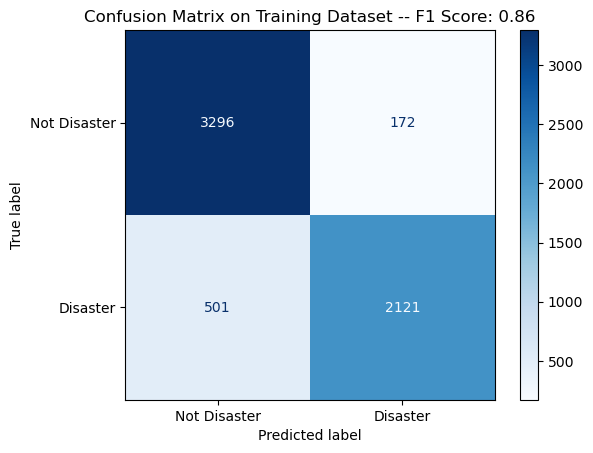

In [12]:
y_pred_train = classifier.predict(X_train)

displayConfusionMatrix(y_train, y_pred_train, "Training")

48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step


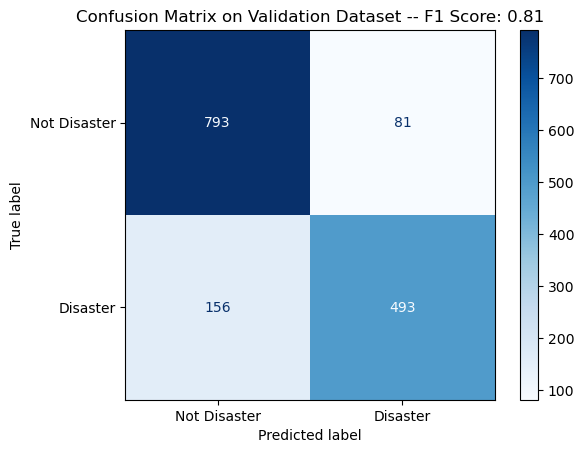

In [13]:
y_pred_val = classifier.predict(X_val)

displayConfusionMatrix(y_val, y_pred_val, "Validation")

## 7) Conclusion
_Discuss and interpret results as well as learnings and takeaways. What did and did not help improve the performance of your models? What improvements could you try in the future?_



## 8) Kaggle Submission
For each tweet in the test set, we predict if the given tweet is about a real disaster or not. If so, predict a 1. If not, predict a 0. The `submission.csv` file uses the following format:
`id,target`

In [15]:
sample_submission["target"] = np.argmax(classifier.predict(X_test), axis=1)

102/102 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step


In [16]:
sample_submission.describe()

,id,target
count,3263.000000,3263.000000
mean,5427.152927,0.361630
std,3146.427221,0.480546
min,0.000000,0.000000
25%,2683.000000,0.000000
50%,5500.000000,0.000000
75%,8176.000000,1.000000
max,10875.000000,1.000000


In [17]:
sample_submission.to_csv("submission.csv", index=False)

## 9) Citations

1) My startpoint was the starter notebook provided by the Keras team. https://keras.io/guides/keras_nlp/getting_started/
2) This notebook on Kaggle from Guines Evitan was extremely helpful: https://www.kaggle.com/code/gunesevitan/nlp-with-disaster-tweets-eda-cleaning-and-bert